In [ ]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [ ]:
print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
# Check target distribution
print(df['Attrition'].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [ ]:
# Missing values
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [ ]:
df = df.drop(['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'], axis=1)

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
scaler = StandardScaler()

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

#**Sigmoid**

In [ ]:
model_sigmoid = Sequential([
    Dense(32, activation='sigmoid', input_dim=X.shape[1]),
    Dense(16, activation='sigmoid'),
    Dense(1, activation='sigmoid')
])

model_sigmoid.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_sigmoid.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8138 - loss: 0.5357
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8316 - loss: 0.4443
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8316 - loss: 0.4273
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8316 - loss: 0.4136
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8316 - loss: 0.4007
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8316 - loss: 0.3875
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8316 - loss: 0.3754
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8367 - loss: 0.3627
Epoch 9/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8512 - loss: 0.3525
Epoch 10/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8580 - loss: 0.3435
Epoch 11/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8665 - loss: 0.3367
Epoch 12/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8699 - lo

In [ ]:
model_sigmoid2 = Sequential([
    Dense(32, activation='sigmoid', input_dim=X.shape[1]),
    Dense(16, activation='sigmoid'),
    Dense(1, activation='sigmoid')
])
optimizer = Adam(learning_rate=0.001)
model_sigmoid2.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

model_sigmoid2.fit(X_train, y_train, epochs=20, batch_size=64, verbose=1)

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8316 - loss: 0.4756
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8316 - loss: 0.4503 
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8316 - loss: 0.4427 
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8316 - loss: 0.4372 
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8316 - loss: 0.4312 
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8316 - loss: 0.4239 
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8316 - loss: 0.4171 
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8316 - loss: 0.4108 
Epoch 9/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8316 - loss: 0.4027 
Epoch 10/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8316 - loss: 0.3955 
Epoch 11/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8316 - loss: 0.3884 
Epoch 12/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0

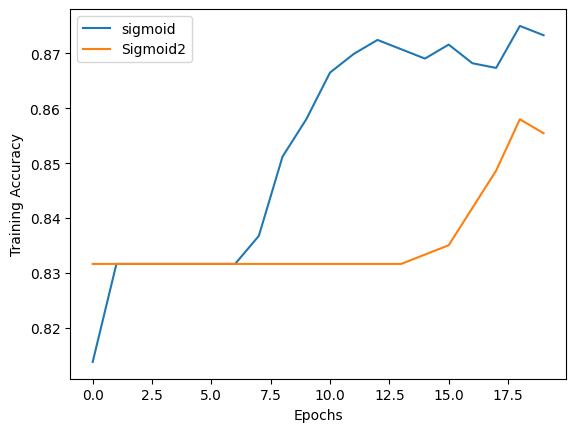

In [ ]:
import matplotlib.pyplot as plt

plt.plot(model_sigmoid.history.history['accuracy'], label='sigmoid')
plt.plot(model_sigmoid2.history.history['accuracy'], label='Sigmoid2')
plt.xlabel('Epochs')
plt.ylabel('Training Accuracy')
plt.legend()
plt.show()

In [ ]:
print("Sigmoid Accuracy:", model_sigmoid.evaluate(X_test, y_test)[1])
print("Sigmoid2 Accuracy:", model_sigmoid2.evaluate(X_test, y_test)[1])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8912 - loss: 0.3192  
Sigmoid Accuracy: 0.8911564350128174
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8810 - loss: 0.3258  
Sigmoid2 Accuracy: 0.8809523582458496


#**Relu**

In [ ]:
model_relu = Sequential([
    Dense(32, activation='relu', input_dim=X.shape[1]),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_relu.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_relu.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7959 - loss: 0.5036
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8367 - loss: 0.4048
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8512 - loss: 0.3688
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8673 - loss: 0.3449
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8741 - loss: 0.3267
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8793 - loss: 0.3138
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8827 - loss: 0.3024
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8844 - loss: 0.2931
Epoch 9/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8895 - loss: 0.2853
Epoch 10/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8929 - loss: 0.2764
Epoch 11/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8946 - loss: 0.2692
Epoch 12/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8988 - lo

In [ ]:
model_relu2 = Sequential([
    Dense(32, activation='relu', input_dim=X.shape[1]),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
optimizer=Adam(learning_rate=0.001)
model_relu2.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

model_relu2.fit(X_train, y_train, epochs=10, batch_size=34, verbose=1)

Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7730 - loss: 0.5574
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8316 - loss: 0.4504
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8316 - loss: 0.4164
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8342 - loss: 0.3944
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8376 - loss: 0.3758
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8537 - loss: 0.3588
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8605 - loss: 0.3437
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8597 - loss: 0.3319
Epoch 9/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8707 - loss: 0.3198
Epoch 10/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8733 - loss: 0.3113


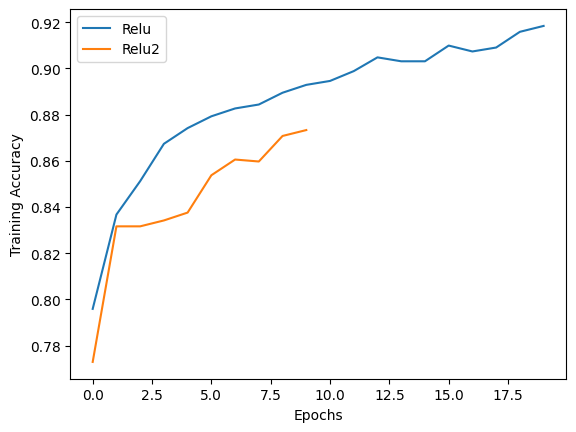

In [ ]:
import matplotlib.pyplot as plt

plt.plot(model_relu.history.history['accuracy'], label='Relu')
plt.plot(model_relu2.history.history['accuracy'], label='Relu2')
plt.xlabel('Epochs')
plt.ylabel('Training Accuracy')
plt.legend()
plt.show()

In [ ]:
print("Relu Accuracy:", model_relu.evaluate(X_test, y_test)[1])
print("Relu2 Accuracy:", model_relu2.evaluate(X_test, y_test)[1])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8878 - loss: 0.3396  
Relu Accuracy: 0.8877550959587097
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8912 - loss: 0.3326  
Relu2 Accuracy: 0.8911564350128174


#**Tanh**

In [ ]:
model_tanh = Sequential([
    Dense(32, activation='tanh', input_dim=X.shape[1]),
    Dense(16, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model_tanh.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_tanh.fit(X_train, y_train, epochs=20, batch_size=36, verbose=1)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5774 - loss: 0.6721
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7568 - loss: 0.5390
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8223 - loss: 0.4575
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8452 - loss: 0.3997
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8580 - loss: 0.3616
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8656 - loss: 0.3417
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8639 - loss: 0.3281
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8716 - loss: 0.3189
Epoch 9/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8750 - loss: 0.3132
Epoch 10/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8690 - loss: 0.3088
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8784 - loss: 0.3040
Epoch 12/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8818 - lo

In [ ]:
model_tanh2 = Sequential([
    Dense(32, activation='tanh', input_dim=X.shape[1]),
    Dense(16, activation='tanh'),
    Dense(1, activation='sigmoid')
])
optimizer=Adam(learning_rate=0.01)
model_tanh2.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

model_tanh2.fit(X_train, y_train, epochs=5, batch_size=64, verbose=1)

Epoch 1/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7364 - loss: 0.5383
Epoch 2/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8665 - loss: 0.3416 
Epoch 3/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8699 - loss: 0.3143 
Epoch 4/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8750 - loss: 0.2996 
Epoch 5/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8895 - loss: 0.2785 


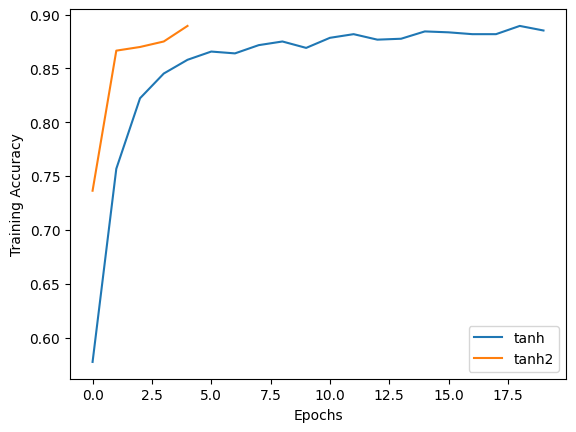

In [ ]:
import matplotlib.pyplot as plt

plt.plot(model_tanh.history.history['accuracy'], label='tanh')
plt.plot(model_tanh2.history.history['accuracy'], label='tanh2')
plt.xlabel('Epochs')
plt.ylabel('Training Accuracy')
plt.legend()
plt.show()

In [ ]:
print("Tanh Accuracy:", model_tanh.evaluate(X_test, y_test)[1])
print("Tanh2 Accuracy:", model_tanh2.evaluate(X_test, y_test)[1])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8707 - loss: 0.3337  
Tanh Accuracy: 0.8707482814788818
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9116 - loss: 0.3208  
Tanh2 Accuracy: 0.9115646481513977


#Model Evalution

In [ ]:
print("Sigmoid Accuracy:", model_sigmoid.evaluate(X_test, y_test)[1])
print("Sigmoid2 Accuracy:", model_sigmoid2.evaluate(X_test, y_test)[1])
print("ReLU Accuracy:", model_relu.evaluate(X_test, y_test)[1])
print("ReLU2 Accuracy:", model_relu2.evaluate(X_test, y_test)[1])
print("Tanh Accuracy:", model_tanh.evaluate(X_test, y_test)[1])
print("Tanh2 Accuracy:", model_tanh2.evaluate(X_test, y_test)[1])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8912 - loss: 0.3192 
Sigmoid Accuracy: 0.8911564350128174
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8810 - loss: 0.3258 
Sigmoid2 Accuracy: 0.8809523582458496
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8878 - loss: 0.3396 
ReLU Accuracy: 0.8877550959587097
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8912 - loss: 0.3326 
ReLU2 Accuracy: 0.8911564350128174
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8707 - loss: 0.3337 
Tanh Accuracy: 0.8707482814788818
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9116 - loss: 0.3208 
Tanh2 Accuracy: 0.9115646481513977


In [ ]:
from sklearn.metrics import classification_report

y_pred = (model_sigmoid2.predict(X_test) > 0.5).astype(int)

print(classification_report(y_test, y_pred))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       255
           1       1.00      0.10      0.19        39

    accuracy                           0.88       294
   macro avg       0.94      0.55      0.56       294
weighted avg       0.90      0.88      0.84       294

